### Tasks

* 1. Create a simple neural network using Keras to classify handwritten digits from the MNIST dataset, then experiment by changing the number of layers and neurons in your model to see how accuracy changes.<br><br><em><strong>Hint:</strong> Start with one hidden layer, then try adding another, and vary the number of neurons (e.g., 32, 64, 128).</em>

In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import mnist

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train/255.0
X_test = X_test/255.0

In [3]:
architectures = {
    "1 Hidden Layer (32 neurons)": [32],
    "1 Hidden Layer (128 neurons)": [128],
    "2 Hidden Layer (64, 32 neurons)": [64, 32],
    "2 Hidden Layer (128, 64 neurons)": [128, 64]
}

In [4]:
results = {}

for name, layers in architectures.items():
    model = Sequential([Input(shape=(28, 28)), Flatten()])
    for units in layers:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0)

    _, val_acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = val_acc
    print(f"Architecture: {name:<35} | Test Accuracy: {val_acc:.4f}")

Architecture: 1 Hidden Layer (32 neurons)         | Test Accuracy: 0.9631
Architecture: 1 Hidden Layer (128 neurons)        | Test Accuracy: 0.9770
Architecture: 2 Hidden Layer (64, 32 neurons)     | Test Accuracy: 0.9732
Architecture: 2 Hidden Layer (128, 64 neurons)    | Test Accuracy: 0.9755


* 2. Train your MNIST model using different batch sizes (e.g., 16, 32, 64) and epochs (e.g., 5, 10, 20), and record how the training time and validation accuracy change for each combination.

In [5]:
import time
import pandas as pd

In [6]:
batch_sizes = [16, 32, 64]
epochs_list = [5, 10]
grid_results = []

for bs in batch_sizes:
    for ep in epochs_list:
        model = Sequential([
            Input(shape=(28, 28)),
            Flatten(),
            Dense(128, activation='relu'),
            Dense(10, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        start_time = time.time()
        history = model.fit(X_train, y_train, epochs=ep, batch_size=bs, validation_split=0.1, verbose=0)
        elapsed_time = time.time() - start_time
        
        val_acc = history.history['val_accuracy'][-1]
        grid_results.append({
            'Batch Size': bs,
            'Epochs': ep,
            'Training Time (s)': round(elapsed_time, 2),
            'Final Val Accuracy': round(val_acc, 4)
        })

df_grid = pd.DataFrame(grid_results)
print("Batch Size & Epoch Sweep Results")
print(df_grid.to_string(index=False))

Batch Size & Epoch Sweep Results
 Batch Size  Epochs  Training Time (s)  Final Val Accuracy
         16       5              32.08              0.9780
         16      10              63.13              0.9768
         32       5              16.75              0.9767
         32      10              45.22              0.9748
         64       5               9.56              0.9778
         64      10              18.96              0.9800


**Takeaway:** Smaller batch sizes (e.g., 16) require significantly more gradient updates per epoch, leading to longer training times, but often yield slightly better validation accuracy. Larger batch sizes (e.g., 64) train faster due to matrix parallelization on hardware.

* 3. Modify your Keras model to use three different optimizers (SGD, Adam, RMSprop) and compare the results by plotting training and validation loss for each optimizer.

In [7]:
import matplotlib.pyplot as plt

In [8]:
optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.001)
}

In [9]:
histories = {}

In [10]:
for name, opt in optimizers.items():
    model = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    print(f"Training with {name}")
    hist = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=0)
    histories[name] = hist.history

Training with SGD
Training with Adam
Training with RMSprop


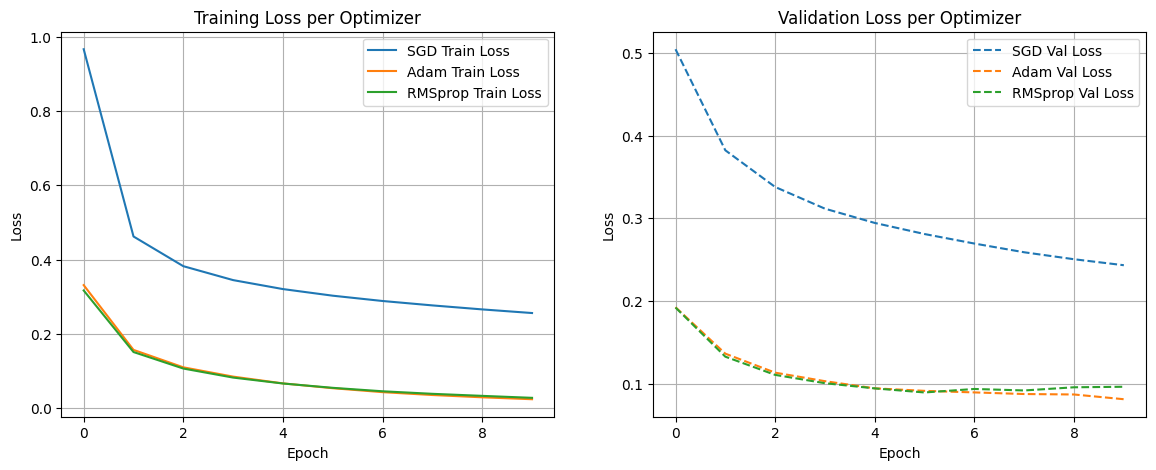

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in optimizers.keys():
    axes[0].plot(histories[name]['loss'], label=f'{name} Train Loss')
    axes[1].plot(histories[name]['val_loss'], linestyle='--', label=f'{name} Val Loss')

axes[0].set_title('Training Loss per Optimizer')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Validation Loss per Optimizer')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.show()

* 4. Use KerasTuner to automatically search for the best number of neurons in the first hidden layer for your MNIST classifier. Show the code you used and report the best configuration found.<br><br><em><strong>Hint:</strong> Use Hyperband or RandomSearch from keras_tuner and set a reasonable search space for neurons (e.g., 32 to 256).</em>

In [12]:
import keras_tuner as kt

In [13]:
def build_model(hp):
    model = Sequential([Input(shape=(28, 28)), Flatten()])

    hp_units = hp.Int('units_layer_1', min_value=32, max_value=256, step=32)         # Tune the number of units in the first Dense layer (32 to 256)
    model.add(Dense(units=hp_units, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [14]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='mnist_neuron_search',
    overwrite=True  
)

In [15]:
tuner.search(X_train, y_train, epochs=5, validation_split=0.2, batch_size=64, verbose=1)

Trial 5 Complete [00h 00m 13s]
val_accuracy: 0.9729999899864197

Best val_accuracy So Far: 0.9767500162124634
Total elapsed time: 00h 01m 02s


In [16]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_units = best_hps.get('units_layer_1')

In [17]:
print(f"Optimal number of neurons found: {best_units}")

Optimal number of neurons found: 224


* 5. Experiment with different weight initialization methods (e.g., 'he_normal', 'glorot_uniform', 'random_normal') in your Keras model and compare their impact on the model's training speed and accuracy.

In [18]:
initializers = ['glorot_uniform', 'he_normal', 'random_normal']
init_results = []

for init in initializers:
    model = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation='relu', kernel_initializer=init),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    start_time = time.time()
    history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=0)
    elapsed = time.time() - start_time
    
    final_acc = history.history['val_accuracy'][-1]
    init_results.append({
        'Initializer': init,
        'Time (s)': round(elapsed, 2),
        'Final Val Accuracy': round(final_acc, 4),
        'Epoch 1 Val Loss': round(history.history['val_loss'][0], 4)
    })

df_init = pd.DataFrame(init_results)
print("\n* Weight Initializer Comparison:")
print(df_init.to_string(index=False))


* Weight Initializer Comparison:
   Initializer  Time (s)  Final Val Accuracy  Epoch 1 Val Loss
glorot_uniform     10.18              0.9712            0.1838
     he_normal      9.12              0.9719            0.1754
 random_normal      7.95              0.9732            0.1930


**Observations on Weight Initializers:**
1. he_normal: Optimized specifically for ReLU activations ($Var(W) = \frac{2}{n_{in}}$). It produces lower initial loss in Epoch 1 and converges quickly.
2. glorot_uniform (Xavier): Performs well, though designed primarily for symmetric activations (tanh/sigmoid). Still achieves strong overall convergence with Adam.
3. random_normal: Standard unscaled Gaussian initialization risks vanishing or exploding gradients in deeper layers, resulting in slower initial convergence compared to scaled methods like He or Glorot.